# Knee Injuries Classification Project
## MRNet Classifier Notebook --> TRAINING A Multi-View 2D-CNN with a Transformer Head

- Use a shared ResNet-18 for all three views.
- Concatenate the features from Axial, Coronal, and Sagittal views into one long vector.
- Use a Transformer Encoder layer (Self-Attention) to let the model decide which slices and which views are the most important for the diagnosis.
- Using a weighted loss --> if acl tears are 4x as less likely as non-acl tears, penalize missing acl tears 4x as much

### Data source:
#### Stanford AIMI. (2026). MRNet: Knee MRI's (Version 1.0) [Dataset]. Redivis. https://stanford.redivis.com/datasets/4a2c-4cpkzrn2c?v=1.0


In [1]:
# MRNet Environment Setup (Run this cell first)
from google.colab import drive
import sys
import os
import zipfile
import shutil

### Only use the following code when you want to add the zipped folder to your drive.
This might take up to 40 minutes to run but it is a one time thing. If you can somehow create the .zip folder in your drive than you do not need to run this code.

In [3]:
drive.mount('/content/drive')
# 1. Define paths
# SOURCE: Your mounted Google Drive folder

Mounted at /content/drive


In [ ]:


# # since you might have the files in a subfolder, make sure to create a folder shortcut in your Drive for easier access
# shared_folder_path = '/content/drive/MyDrive/MLII Final/Data/mrnet_images'

# # DESTINATION: The local, ultra-fast Colab cloud SSD storage
# local_zip_path = '/content/drive/MyDrive/MLII Final/Data/mrnet_images.zip'

# print("Starting optimized compression onto local cloud SSD...")

# # 2. Zip from Drive directly to the local cloud SSD
# !zip -rq "{local_zip_path}" "{shared_folder_path}"

# print("Compression to local SSD complete! Now uploading the single file back to your Drive...")

# # # 3. Copy the single large zip back to Google Drive in one efficient burst
# # !cp "{local_zip_path}" "/content/drive/MyDrive/"

# print("All done! Your optimized 'mrnet_images.zip' is now saved in your Google Drive.")

### Loading data into colab SSD
When we already have your zip folder, we can start from here to git the data unziped inside the colab SSD.

In [4]:
# 1. Mount persistent storage
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [16]:
!ls "/content/drive/MyDrive/MLII Final"

 best_mri_transformer.pth
 best_mri_transformer_v2.pth
 Data
'MRNet Project_ Cloud Environment Architecture and Workflow Guide.pdf'
 Proposal.gdoc
 training_results_v2.png


In [17]:
import os
if os.path.exists('/content/mrnet_images.zip'):
    os.remove('/content/mrnet_images.zip')
    print("Corrupted local zip removed. Please run your main cell again.")

In [18]:
zip_source = '/content/drive/MyDrive/MLII Final/Data/mrnet_images.zip'

# 2. Point to the LOCAL Colab environment for the copy destination
zip_local = '/content/mrnet_images.zip'

# 3. Where the final unzipped images should live
final_image_dir = '/content/mrnet_images'
extract_to = '/content/'

# ==========================================
# RUN EXTRACTION SEQUENCE
# ==========================================
if not os.path.exists(final_image_dir):

    # Safety Check: Verify the zip file actually exists on Drive
    if not os.path.exists(zip_source):
        raise FileNotFoundError(f"Could not find your zip file at: {zip_source}. Double check the file name extension!")

    # Step A: Copy the zip from Drive to local SSD if it's missing
    if not os.path.exists(zip_local):
        print("Transferring optimized archive from Drive to local cloud SSD...")
        shutil.copy(zip_source, zip_local)
        print("Transfer complete! Starting extraction...")

    # Step B: Unzip with the visible progress counter
    print("Opening zip archive securely...")
    with zipfile.ZipFile(zip_local, 'r') as zip_ref:
        files = zip_ref.namelist()
        total_files = len(files)
        print(f"Total files to extract: {total_files}")

        # Discover the top-level directory name inside the zip file dynamically
        # (Usually 'MRNet-v1.0/' or 'mrnet/')
        top_level_internal_dir = files[0].split('/')[0]

        for index, file in enumerate(files):
            zip_ref.extract(file, extract_to)
            if index % 500 == 0 and index > 0:
                print(f"-> Extracted {index}/{total_files} files... ({int(index/total_files*100)}%)")

    print("Unpacking complete!")

    # Step C: Fix the path nesting structure automatically
    # Dynamically maps whatever folder name was inside the zip straight to '/content/mrnet_images'
    internal_extracted_path = os.path.join('/content', top_level_internal_dir)

    if os.path.exists(internal_extracted_path):
        print(f"Correcting zip path nesting structure: Renaming {internal_extracted_path} to {final_image_dir}...")
        os.rename(internal_extracted_path, final_image_dir)

    # Step D: Clean up the local copy of the zip file to save SSD space
    if os.path.exists(zip_local):
        os.remove(zip_local)
        print("Temporary local zip cleared from scratch disk.")

    print("Environment Setup Perfected!")
else:
    print("Data already unpacked and ready on local SSD.")

Transferring optimized archive from Drive to local cloud SSD...
Transfer complete! Starting extraction...
Opening zip archive securely...
Total files to extract: 3580
-> Extracted 500/3580 files... (13%)
-> Extracted 1000/3580 files... (27%)
-> Extracted 1500/3580 files... (41%)
-> Extracted 2000/3580 files... (55%)
-> Extracted 2500/3580 files... (69%)
-> Extracted 3000/3580 files... (83%)
-> Extracted 3500/3580 files... (97%)
Unpacking complete!
Correcting zip path nesting structure: Renaming /content/content to /content/mrnet_images...
Temporary local zip cleared from scratch disk.
Environment Setup Perfected!


### Importing .py file

In [ ]:
import importlib
# 1. Clone the repository if it doesn't exist on the cloud machine yet
repo_path = '/content/CNN_ClassModeling'

if not os.path.exists(repo_path):
    print("Cloning the code repository from GitHub...")
    !git clone https://github.com/AbdulAlbaqami/Knee_Injuries_Classification_Model_MRI_Images.git {repo_path}
else:
    print("Repository already exists. Pulling latest updates...")
    !cd {repo_path} && git pull

# 2. Inject the repository path into Python's system search path
if repo_path not in sys.path:
    sys.path.append(repo_path)

# 3. Safe Module Import / Reload Logic
import loading_data as ld
# If teammates update the file and you pull it, this line forces Python to update its cache
importlib.reload(ld)

print("Successfully imported loading_data.py module!")

Cloning the code repository from GitHub...
Cloning into '/content/CNN_ClassModeling'...
remote: Enumerating objects: 27, done.
remote: Counting objects: 100% (27/27), done.
remote: Compressing objects: 100% (22/22), done.
remote: Total 27 (delta 8), reused 23 (delta 4), pack-reused 0 (from 0)
Receiving objects: 100% (27/27), 535.86 KiB | 17.29 MiB/s, done.
Resolving deltas: 100% (8/8), done.
Successfully imported loading_data.py module!


In [ ]:
import numpy as np

# Load a single case
sample_volume = np.load('/content/mrnet_images/drive/MyDrive/MLII Final/Data/mrnet_images/axial/0228.npy')

print("Data Type:", type(sample_volume))
print("Volume Shape:", sample_volume.shape)

Data Type: <class 'numpy.ndarray'>
Volume Shape: (24, 256, 256)


In [ ]:
ls "/content/mrnet_images/drive/MyDrive/MLII Final/Data/mrnet_images/valid_files"

axial/  coronal/  sagittal/


# Neural Network

In [106]:
import os, cv2
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as T
from torchvision.models import resnet18, ResNet18_Weights
import matplotlib.pyplot as plt
from tqdm.auto import tqdm
from sklearn.metrics import roc_auc_score, roc_curve, auc as sk_auc

# ── Paths ──────────────────────────────────────────────────────────
BASE_DIR      = '/content/mrnet_images/drive/MyDrive/MLII Final/Data/mrnet_images'
MASTER_CSV    = '/content/drive/MyDrive/MLII Final/Data/unified_labels.csv'
SAVE_PATH     = '/content/drive/MyDrive/MLII Final/best_mrnet_stage4.pth'
PRETRAIN_PATH = '/content/drive/MyDrive/MLII Final/stage4_contrastive_backbone.pth'

# ── Hyper-parameters ───────────────────────────────────────────────
BATCH_SIZE         = 2
ACCUMULATION_STEPS = 4          # effective batch = 8
EPOCHS             = 15
MAX_SLICES         = 40
TOP_K_SLICES       = 20         # slices kept per view after pre-filtering
D_FUSION           = 512        # fusion MLP hidden dim
FOCAL_GAMMA        = 2.0
LR                 = 3e-4
WEIGHT_DECAY       = 1e-2
FREEZE_EPOCHS      = 10         # unfreeze at ep20/30 (~LR 4e-6) — same late-unfreeze strategy scaled to 30 epochs

# ── Dual Attention ──────────────────────────────────────────────────
ATTN_REDUCTION  = 16            # SE channel reduction ratio
SPATIAL_KERNEL  = 7             # spatial attention conv kernel

# ── Contrastive Pretraining (optional) ─────────────────────────────
RUN_PRETRAIN       = False      # ← set True to enable
PRETRAIN_EPOCHS    = 10
PRETRAIN_LR        = 1e-3
PRETRAIN_BATCH     = 8
CONTRASTIVE_DIM    = 128
CONTRASTIVE_TEMP   = 0.07

# ── Class imbalance weights ─────────────────────────────────────────
ACL_POS_WEIGHT = 4.07           # 757/186
MEN_POS_WEIGHT = 1.83           # 610/333
ABN_POS_WEIGHT = 1.0            # 80% positive — no boost needed; 2.5 caused pred_mean collapse to 0.85

SUBSET_RATIO = 1.0              # full dataset

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device       : {DEVICE}")
print(f"Top-K slices : {TOP_K_SLICES}/{MAX_SLICES} per view after pre-filter")
print(f"D_FUSION     : {D_FUSION}   Subset: {int(SUBSET_RATIO*100)}%")
print(f"Contrastive pretraining: {'ENABLED' if RUN_PRETRAIN else 'DISABLED (set RUN_PRETRAIN=True to enable)'}")


Device       : cuda
Top-K slices : 20/40 per view after pre-filter
D_FUSION     : 512   Subset: 100%
Contrastive pretraining: DISABLED (set RUN_PRETRAIN=True to enable)


In [107]:
class MRNetDataset(Dataset):
    """
    Returns per-sample:
      ax, cor, sag : (MAX_SLICES, 3, 224, 224)  float tensors
      mask         : (MAX_SLICES,)               bool — True = PADDING (to be ignored)
      label        : (3,)                        [acl, meniscus, abnormal]

    The mask is shared across views (same slices are real/padding in all views).
    Volumes shorter than MAX_SLICES are right-padded with zeros; mask marks those.
    """
    SPLIT_SUBDIR = {'train': '', 'valid': 'valid_files'}

    def __init__(self, base_dir, csv_path, split='train',
                 subset_ratio=1.0, max_slices=40, augment=False):
        self.base_dir   = base_dir
        self.split      = split
        self.max_slices = max_slices
        self.subdir     = self.SPLIT_SUBDIR[split]

        df = pd.read_csv(csv_path)
        self.labels = df[df['split'] == split].copy()
        self.labels['exam_id'] = self.labels['exam_id'].astype(str).str.zfill(4)

        if subset_ratio < 1.0 and split == 'train':
            self.labels = self.labels.sample(
                frac=subset_ratio, random_state=42).reset_index(drop=True)

        aug_steps = [
            T.ToPILImage(), T.Resize((224, 224)),
            T.RandomHorizontalFlip(p=0.5),
            T.RandomRotation(degrees=10),
        ] if augment else [T.ToPILImage(), T.Resize((224, 224))]

        self.transform = T.Compose(aug_steps + [
            T.ToTensor(),
            T.Normalize(mean=[0.485, 0.456, 0.406],
                        std =[0.229, 0.224, 0.225])
        ])

    def _build_path(self, view, pid):
        if self.subdir:
            return os.path.join(self.base_dir, self.subdir, view, f'{pid}.npy')
        return os.path.join(self.base_dir, view, f'{pid}.npy')

    def _load_volume(self, path):
        vol = np.load(path).astype(np.float32)
        v_min, v_max = vol.min(), vol.max()
        if v_max - v_min > 1e-6:
            vol = (vol - v_min) / (v_max - v_min) * 255.0
        vol = vol.astype(np.uint8)

        s, h, w  = vol.shape
        n_real   = min(s, self.max_slices)   # actual slice count before padding

        # Centre-crop if too long
        if s > self.max_slices:
            start = (s - self.max_slices) // 2
            vol   = vol[start : start + self.max_slices]
            s     = self.max_slices

        slices = []
        for i in range(s):
            rgb = np.stack([vol[i]] * 3, axis=-1)
            slices.append(self.transform(rgb))

        # Zero-pad to MAX_SLICES
        if s < self.max_slices:
            pad_slice = torch.zeros_like(slices[0])
            slices   += [pad_slice] * (self.max_slices - s)

        # Padding mask: True = padding token (to be IGNORED by Transformer)
        mask = torch.zeros(self.max_slices, dtype=torch.bool)
        mask[n_real:] = True

        return torch.stack(slices), mask   # (S, 3, H, W),  (S,)

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        row = self.labels.iloc[idx]
        pid = row['exam_id']

        ax,  mask_ax  = self._load_volume(self._build_path('axial',    pid))
        cor, mask_cor = self._load_volume(self._build_path('coronal',  pid))
        sag, mask_sag = self._load_volume(self._build_path('sagittal', pid))

        # All views have the same number of slices per exam
        # (same physical scan), so one mask covers all three
        lbl = torch.tensor(
            [row['acl'], row['meniscus'], row['abnormal']],
            dtype=torch.float32)

        return ax, cor, sag, mask_ax, lbl


In [108]:
train_dataset = MRNetDataset(BASE_DIR, MASTER_CSV, split='train',
                              max_slices=MAX_SLICES, augment=True,
                              subset_ratio=SUBSET_RATIO)
valid_dataset = MRNetDataset(BASE_DIR, MASTER_CSV, split='valid',
                              max_slices=MAX_SLICES, augment=False)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE,
                          shuffle=True,  num_workers=0, pin_memory=True)
valid_loader = DataLoader(valid_dataset, batch_size=BATCH_SIZE,
                          shuffle=False, num_workers=0, pin_memory=True)

print(f"Train samples : {len(train_dataset)}")
print(f"Valid samples : {len(valid_dataset)}")

# ── Path check ────────────────────────────────────────────────────
def check_paths(dataset, label=''):
    row = dataset.labels.iloc[0]
    pid = row['exam_id']
    for view in ['axial', 'coronal', 'sagittal']:
        p = dataset._build_path(view, pid)
        print(f"  {'✓' if os.path.exists(p) else '✗ MISSING'} [{label}] {p}")

check_paths(train_dataset, 'train')
check_paths(valid_dataset, 'valid')

# Sanity check tensor shapes + mask
ax, cor, sag, mask, lbl = train_dataset[0]
print(f"\nAxial  : {ax.shape}   mask real slices: {(~mask).sum().item()}/{MAX_SLICES}")
print(f"Labels : {lbl}")


Train samples : 943
Valid samples : 119
  ✓ [train] /content/mrnet_images/drive/MyDrive/MLII Final/Data/mrnet_images/axial/1027.npy
  ✓ [train] /content/mrnet_images/drive/MyDrive/MLII Final/Data/mrnet_images/coronal/1027.npy
  ✓ [train] /content/mrnet_images/drive/MyDrive/MLII Final/Data/mrnet_images/sagittal/1027.npy
  ✓ [valid] /content/mrnet_images/drive/MyDrive/MLII Final/Data/mrnet_images/valid_files/axial/1139.npy
  ✓ [valid] /content/mrnet_images/drive/MyDrive/MLII Final/Data/mrnet_images/valid_files/coronal/1139.npy
  ✓ [valid] /content/mrnet_images/drive/MyDrive/MLII Final/Data/mrnet_images/valid_files/sagittal/1139.npy

Axial  : torch.Size([40, 3, 224, 224])   mask real slices: 24/40
Labels : tensor([0., 0., 0.])


In [109]:
# ─────────────────────────────────────────────────────────────────────────────
# 4a · Dual Attention Module (CBAM-style)
# ─────────────────────────────────────────────────────────────────────────────

class ChannelAttention(nn.Module):
    """SE-style: avg-pool + max-pool both through shared MLP, then sigmoid-scale."""
    def __init__(self, channels: int, reduction: int = 16):
        super().__init__()
        mid = max(channels // reduction, 8)
        self.avg_pool = nn.AdaptiveAvgPool2d(1)
        self.max_pool = nn.AdaptiveMaxPool2d(1)
        self.fc = nn.Sequential(
            nn.Linear(channels, mid, bias=False),
            nn.ReLU(inplace=True),
            nn.Linear(mid, channels, bias=False),
        )

    def forward(self, x):
        avg   = self.fc(self.avg_pool(x).flatten(1))
        mx    = self.fc(self.max_pool(x).flatten(1))
        scale = torch.sigmoid(avg + mx).view(x.size(0), x.size(1), 1, 1)
        return x * scale


class SpatialAttention(nn.Module):
    """CBAM spatial: channel avg+max → 2-ch conv → sigmoid map."""
    def __init__(self, kernel_size: int = 7):
        super().__init__()
        self.conv = nn.Conv2d(2, 1, kernel_size, padding=kernel_size//2, bias=False)

    def forward(self, x):
        avg_map = x.mean(dim=1, keepdim=True)
        max_map = x.max( dim=1, keepdim=True).values
        scale   = torch.sigmoid(self.conv(torch.cat([avg_map, max_map], dim=1)))
        return x * scale


class DualAttention(nn.Module):
    """Channel attention → Spatial attention (sequential CBAM order)."""
    def __init__(self, channels: int,
                 reduction: int = 16, spatial_kernel: int = 7):
        super().__init__()
        self.channel = ChannelAttention(channels, reduction)
        self.spatial = SpatialAttention(spatial_kernel)

    def forward(self, x):
        return self.spatial(self.channel(x))


# ─────────────────────────────────────────────────────────────────────────────
# 4b · Slice Pre-Filter
# ─────────────────────────────────────────────────────────────────────────────

class SliceScorer(nn.Module):
    """
    Lightweight CNN that scores each slice for informativeness.
    Architecture: three conv-BN-ReLU blocks with stride-2 downsampling,
    global avg pool, single linear output (higher = more informative).

    Trained jointly with the main model via a differentiable top-K selection:
    scores are computed for all MAX_SLICES slices; the top-K by score are
    selected. Padded slices are masked to score = -inf before selection.

    The scorer uses a small 32/64/128-channel network — cheap enough to run
    on every slice without being the bottleneck.
    """
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(3, 32,  3, stride=2, padding=1), nn.BatchNorm2d(32),  nn.ReLU(inplace=True),
            nn.Conv2d(32, 64, 3, stride=2, padding=1), nn.BatchNorm2d(64),  nn.ReLU(inplace=True),
            nn.Conv2d(64, 128,3, stride=2, padding=1), nn.BatchNorm2d(128), nn.ReLU(inplace=True),
            nn.AdaptiveAvgPool2d(1),
        )
        self.head = nn.Linear(128, 1)

    def forward(self, x):
        # x: (N, 3, H, W)
        return self.head(self.net(x).flatten(1)).squeeze(-1)   # (N,)


def select_top_k_slices(vol, pad_mask, scorer, top_k, device):
    """
    vol      : (B, S, 3, H, W)
    pad_mask : (B, S)  True = padding
    Returns  : (B, top_k, 3, H, W)  top-k slices per batch item,
               sorted by original slice order (not by score).
    """
    B, S, C, H, W = vol.shape
    flat   = vol.view(B * S, C, H, W)
    scores = scorer(flat).view(B, S)              # (B, S)

    # Mask padding slices to -inf so they are never selected
    scores = scores.masked_fill(pad_mask, float('-inf'))

    _, topk_idx = scores.topk(top_k, dim=1)       # (B, top_k)
    topk_idx, _ = topk_idx.sort(dim=1)            # restore anatomical order

    # Gather slices: (B, top_k, C, H, W)
    idx_exp = topk_idx.unsqueeze(-1).unsqueeze(-1).unsqueeze(-1)
    idx_exp = idx_exp.expand(-1, -1, C, H, W)
    return vol.gather(1, idx_exp)                 # (B, top_k, C, H, W)


# ─────────────────────────────────────────────────────────────────────────────
# 4c · Main Model — No Transformer, Max-Pool Fusion
# ─────────────────────────────────────────────────────────────────────────────

class MRNetDualAttn(nn.Module):
    """
    Stage 4 architecture (transformer-free):

    Per view (axial / coronal / sagittal):
      1. SliceScorer ranks all MAX_SLICES slices; top-K selected.
      2. Shared ResNet-18 backbone encodes each of the K slices.
      3. DualAttention applied on the last conv feature map (512-ch).
      4. Global avg pool → 512-d feature per slice.
      5. Max-pool over the K slice features → 512-d view embedding.

    Fusion:
      6. Concat the three view embeddings → 1536-d.
      7. Fusion MLP (1536 → D_FUSION → 256) shared across tasks.
      8. Three lightweight task heads (256 → 1).
         Abnormality head receives its own deeper MLP (not detached —
         detach was suppressing the abnormality gradient entirely).

    Parameter count is ~10-15M vs ~25M for the transformer variant,
    and the inductive bias (max-pool over slices) is much better suited
    to small-N MRI datasets where the most informative slice dominates.
    """

    def __init__(self, top_k: int = 10, d_fusion: int = 512,
                 reduction: int = 16, spatial_kernel: int = 7):
        super().__init__()
        self.top_k = top_k

        # ── Slice pre-filter ──────────────────────────────────────
        self.scorer = SliceScorer()

        # ── Shared backbone (all layers except avgpool + fc) ──────
        resnet = resnet18(weights=ResNet18_Weights.IMAGENET1K_V1)
        self.backbone_layers = nn.ModuleList(list(resnet.children())[:-2])
        self.global_pool     = nn.AdaptiveAvgPool2d(1)

        # ── Dual attention on 512-ch last feature map ─────────────
        self.dual_attention = DualAttention(512, reduction, spatial_kernel)

        # ── Fusion MLP: 3 views × 512 → d_fusion → 256 ───────────
        self.fusion = nn.Sequential(
            nn.Linear(512 * 3, d_fusion),
            nn.LayerNorm(d_fusion),
            nn.GELU(),
            nn.Dropout(0.3),
            nn.Linear(d_fusion, 256),
            nn.LayerNorm(256),
            nn.GELU(),
            nn.Dropout(0.2),
        )

        # ── Task heads ────────────────────────────────────────────
        # ACL + Meniscus: single linear (fused repr is already rich)
        self.head_acl = nn.Linear(256, 1)
        self.head_men = nn.Linear(256, 1)
        # Abnormality: deeper head — it's a global signal not captured by
        # the same features that localise ACL/meniscus tears
        self.head_abn = nn.Sequential(
            nn.Linear(256, 128),
            nn.LayerNorm(128),
            nn.GELU(),
            nn.Dropout(0.2),
            nn.Linear(128, 1),
        )

    # ──────────────────────────────────────────────────────────────
    def _run_backbone(self, x):
        """x: (N, 3, H, W) → last conv feature map (N, 512, h, w)."""
        for layer in self.backbone_layers:
            x = layer(x)
        return x

    def _encode_view(self, vol, pad_mask):
        """
        vol      : (B, S, 3, H, W)
        pad_mask : (B, S)
        Returns  : (B, 512)  max-pooled view embedding
        """
        # Step 1 — slice pre-filter
        top_slices = select_top_k_slices(
            vol, pad_mask, self.scorer, self.top_k, vol.device
        )                                         # (B, K, 3, H, W)

        B, K, C, H, W = top_slices.shape
        flat = top_slices.view(B * K, C, H, W)

        # Step 2 — backbone
        feat_map = self._run_backbone(flat)       # (B*K, 512, h, w)

        # Step 3 — dual attention
        feat_map = self.dual_attention(feat_map)  # (B*K, 512, h, w)

        # Step 4 — global pool → slice features
        feat = self.global_pool(feat_map).view(B, K, 512)   # (B, K, 512)

        # Step 5 — max-pool over K slices → view embedding
        view_feat = feat.max(dim=1).values        # (B, 512)
        return view_feat

    def forward(self, ax, cor, sag, pad_mask):
        """
        ax, cor, sag : (B, S, 3, H, W)
        pad_mask     : (B, S)  True = padding slice
        """
        f_ax  = self._encode_view(ax,  pad_mask)
        f_cor = self._encode_view(cor, pad_mask)
        f_sag = self._encode_view(sag, pad_mask)

        fused = self.fusion(torch.cat([f_ax, f_cor, f_sag], dim=1))  # (B, 256)

        acl = self.head_acl(fused)
        men = self.head_men(fused)
        abn = self.head_abn(fused)   # NOT detached — detach was killing abnormality gradient
        return acl, men, abn

    # ── Freeze / unfreeze helpers ──────────────────────────────────
    def freeze_bn(self):
        for m in self.backbone_layers.modules():
            if isinstance(m, nn.BatchNorm2d):
                m.eval()
                m.weight.requires_grad = False
                m.bias.requires_grad   = False

    def freeze_backbone(self):
        for p in self.backbone_layers.parameters():
            p.requires_grad = False

    def unfreeze_backbone(self):
        for p in self.backbone_layers.parameters():
            p.requires_grad = True

    def load_pretrained_weights(self, backbone_sd, attention_sd):
        """Transfer weights from optional contrastive pretraining checkpoint."""
        own_sd  = self.state_dict()
        new_sd  = {}
        loaded_bb, loaded_att = 0, 0
        for name, param in own_sd.items():
            if name.startswith('backbone_layers.'):
                key = name[len('backbone_layers.'):]
                if key in backbone_sd and backbone_sd[key].shape == param.shape:
                    new_sd[name] = backbone_sd[key]; loaded_bb += 1; continue
            if name.startswith('dual_attention.'):
                key = name[len('dual_attention.'):]
                if key in attention_sd and attention_sd[key].shape == param.shape:
                    new_sd[name] = attention_sd[key]; loaded_att += 1; continue
            new_sd[name] = param
        self.load_state_dict(new_sd, strict=False)
        print(f"  ✓ Loaded {loaded_bb} backbone + {loaded_att} attention params from contrastive checkpoint.")


In [110]:
# ── Only runs if RUN_PRETRAIN = True ──────────────────────────────
if RUN_PRETRAIN:

    class MRIContrastiveTransform:
        def __init__(self):
            self.aug = T.Compose([
                T.ToPILImage(), T.Resize((224, 224)),
                T.RandomHorizontalFlip(p=0.5),
                T.RandomApply([T.RandomRotation(15)], p=0.8),
                T.RandomApply([T.ColorJitter(brightness=0.3, contrast=0.3)], p=0.5),
                T.ToTensor(),
                T.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225]),
                T.RandomErasing(p=0.3, scale=(0.02,0.12)),
            ])
        def __call__(self, x):
            rgb = np.stack([x]*3, axis=-1)
            return self.aug(rgb), self.aug(rgb)

    class ContrastiveSliceDataset(Dataset):
        def __init__(self, base_dir, csv_path, max_slices=40, subset_ratio=1.0):
            self.transform = MRIContrastiveTransform()
            df = pd.read_csv(csv_path)
            df = df[df['split']=='train'].copy()
            df['exam_id'] = df['exam_id'].astype(str).str.zfill(4)
            if subset_ratio < 1.0:
                df = df.sample(frac=subset_ratio, random_state=42)
            self.index = []
            for _, row in df.iterrows():
                pid = row['exam_id']
                for v in ['axial','coronal','sagittal']:
                    p = os.path.join(base_dir, v, f'{pid}.npy')
                    if os.path.exists(p):
                        n = min(np.load(p, mmap_mode='r').shape[0], max_slices)
                        self.index.extend([(p, s) for s in range(n)])
        def __len__(self): return len(self.index)
        def __getitem__(self, idx):
            path, s = self.index[idx]
            vol = np.load(path).astype(np.float32)
            vmin,vmax = vol.min(),vol.max()
            slc = ((vol[s]-vmin)/(vmax-vmin+1e-6)*255).astype(np.uint8)
            return self.transform(slc)

    class NTXentLoss(nn.Module):
        def __init__(self, temperature=0.07):
            super().__init__(); self.T = temperature
        def forward(self, z1, z2):
            N = z1.size(0)
            z = torch.cat([z1,z2],0)
            sim = torch.mm(z,z.T)/self.T
            sim.fill_diagonal_(float('-inf'))
            labels = torch.cat([torch.arange(N,2*N),torch.arange(N)]).to(z.device)
            return F.cross_entropy(sim, labels)

    class ContrastiveWrapper(nn.Module):
        """Wraps the main model's backbone+attention for pretraining only."""
        def __init__(self, backbone_layers, dual_attention, proj_dim=128):
            super().__init__()
            self.backbone_layers = backbone_layers
            self.dual_attention  = dual_attention
            self.global_pool     = nn.AdaptiveAvgPool2d(1)
            self.projector = nn.Sequential(
                nn.Linear(512, 256, bias=False), nn.BatchNorm1d(256), nn.ReLU(inplace=True),
                nn.Linear(256, proj_dim, bias=False), nn.BatchNorm1d(proj_dim, affine=False),
            )
        def _encode(self, x):
            for layer in self.backbone_layers: x = layer(x)
            x = self.dual_attention(x)
            return self.global_pool(x).flatten(1)
        def forward(self, x1, x2):
            h1 = self._encode(x1); h2 = self._encode(x2)
            return F.normalize(self.projector(h1),1), F.normalize(self.projector(h2),1)

    print("\n═══ Contrastive Pretraining ═══")
    # Build a temporary wrapper around the model's own backbone + attention
    model_c = ContrastiveWrapper(
        model.backbone_layers, model.dual_attention, CONTRASTIVE_DIM
    ).to(DEVICE)

    ds_c = ContrastiveSliceDataset(BASE_DIR, MASTER_CSV,
                                    max_slices=MAX_SLICES, subset_ratio=SUBSET_RATIO)
    ld_c = DataLoader(ds_c, batch_size=PRETRAIN_BATCH, shuffle=True,
                      num_workers=0, pin_memory=True, drop_last=True)
    loss_c  = NTXentLoss(CONTRASTIVE_TEMP).to(DEVICE)
    opt_c   = optim.AdamW(model_c.parameters(), lr=PRETRAIN_LR, weight_decay=1e-4)
    sched_c = optim.lr_scheduler.CosineAnnealingLR(opt_c, T_max=PRETRAIN_EPOCHS, eta_min=1e-5)
    scaler_c = torch.amp.GradScaler('cuda')

    for ep in range(PRETRAIN_EPOCHS):
        model_c.train(); total = 0.0
        for v1, v2 in tqdm(ld_c, desc=f"  Pretrain {ep+1}/{PRETRAIN_EPOCHS}", leave=False):
            v1,v2 = v1.to(DEVICE),v2.to(DEVICE)
            with torch.amp.autocast('cuda'):
                z1,z2 = model_c(v1,v2); l = loss_c(z1,z2)
            scaler_c.scale(l).backward()
            scaler_c.unscale_(opt_c)
            torch.nn.utils.clip_grad_norm_(model_c.parameters(),1.0)
            scaler_c.step(opt_c); scaler_c.update(); opt_c.zero_grad()
            total += l.item()
        sched_c.step()
        print(f"  Ep {ep+1:02d} NT-Xent: {total/len(ld_c):.4f}  LR: {sched_c.get_last_lr()[0]:.2e}")

    torch.save({'backbone': {k:v for k,v in model.backbone_layers.state_dict().items()},
                'attention': {k:v for k,v in model.dual_attention.state_dict().items()}},
               PRETRAIN_PATH)
    print(f"  ✓ Pretrained weights saved → {PRETRAIN_PATH}")
    del model_c, ds_c, ld_c, loss_c, opt_c, sched_c, scaler_c

elif os.path.exists(PRETRAIN_PATH):
    print(f"Loading existing contrastive checkpoint: {PRETRAIN_PATH}")
    ckpt_c = torch.load(PRETRAIN_PATH, map_location=DEVICE)
    model.load_pretrained_weights(ckpt_c['backbone'], ckpt_c['attention'])

else:
    print("Contrastive pretraining skipped — using ImageNet weights.")


Contrastive pretraining skipped — using ImageNet weights.


In [111]:
class FocalMultiTaskLoss(nn.Module):
    """
    Focal Loss per task with class-imbalance pos_weight.
    Task multipliers scaled inversely to positive rate:
      ACL (19.7% pos)  → 5.0
      Meniscus (35.3%) → 2.8
      Abnormality (80%) → 3.5  (raised — global signal needs stronger gradient)
    """
    TASK_MULTIPLIERS = [5.0, 2.8, 3.5]  # raised abn: was 1.0, now matches its difficulty

    def __init__(self, pos_weights: list, gamma: float = 2.0):
        super().__init__()
        self.gamma = gamma
        self.register_buffer('pos_weights',
                              torch.tensor(pos_weights, dtype=torch.float32))

    def forward(self, preds, targets):
        total_loss = 0.0
        loss_parts = []
        for i in range(3):
            logit  = preds[i].squeeze(-1)
            target = targets[:, i].float()
            bce = nn.functional.binary_cross_entropy_with_logits(
                logit, target,
                pos_weight=self.pos_weights[i],
                reduction='none'
            )
            p_t    = torch.exp(-bce)
            f_loss = ((1.0 - p_t) ** self.gamma * bce).mean()
            total_loss = total_loss + self.TASK_MULTIPLIERS[i] * f_loss
            loss_parts.append(f_loss.item())
        return total_loss, loss_parts


In [112]:
model = MRNetDualAttn(
    top_k          = TOP_K_SLICES,
    d_fusion       = D_FUSION,
    reduction      = ATTN_REDUCTION,
    spatial_kernel = SPATIAL_KERNEL,
).to(DEVICE)

criterion = FocalMultiTaskLoss(
    pos_weights=[ACL_POS_WEIGHT, MEN_POS_WEIGHT, ABN_POS_WEIGHT],
    gamma=FOCAL_GAMMA,
).to(DEVICE)

# Three param groups:
#   backbone  → LR/10 (fine-tune carefully)
#   attention + scorer → LR/3 (new modules, but small)
#   fusion + heads     → LR   (fully new)
optimizer = optim.AdamW([
    {'params': model.backbone_layers.parameters(),
     'lr': LR/10, 'weight_decay': WEIGHT_DECAY},
    {'params': list(model.dual_attention.parameters()) +
               list(model.scorer.parameters()),
     'lr': LR/3, 'weight_decay': WEIGHT_DECAY},
    {'params': list(model.fusion.parameters()) +
               list(model.head_acl.parameters()) +
               list(model.head_men.parameters()) +
               list(model.head_abn.parameters()),
     'lr': LR, 'weight_decay': WEIGHT_DECAY},
], lr=LR)

scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS, eta_min=1e-5)   # min LR floor — prevents near-zero updates in final epochs)
scaler    = torch.amp.GradScaler('cuda')

model.freeze_backbone()

total_p     = sum(p.numel() for p in model.parameters())
trainable_p = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Total params    : {total_p:,}")
print(f"Trainable params: {trainable_p:,}  (backbone frozen)")
print(f"Backbone unfreezes at epoch {FREEZE_EPOCHS}")

RESUME = False
start_epoch  = 0
best_val_auc = 0.0

if RESUME and os.path.exists(SAVE_PATH):
    ckpt = torch.load(SAVE_PATH, map_location=DEVICE)
    model.load_state_dict(ckpt['model_state_dict'])
    optimizer.load_state_dict(ckpt['optimizer_state_dict'])
    scheduler.load_state_dict(ckpt['scheduler_state_dict'])
    start_epoch  = ckpt['epoch'] + 1
    best_val_auc = ckpt['auc']
    print(f"Resumed from epoch {start_epoch}  best AUC={best_val_auc:.4f}")


Total params    : 12,256,806
Trainable params: 1,080,294  (backbone frozen)
Backbone unfreezes at epoch 10


In [113]:
def get_accuracy(logits, targets):
    return ((torch.sigmoid(logits) > 0.5).float() == targets).float().mean().item()

history = {
    'train_loss': [], 'val_loss': [],
    'train_acl_acc': [], 'train_men_acc': [], 'train_abn_acc': [],
    'val_acl_acc':   [], 'val_men_acc':   [], 'val_abn_acc':   [],
    'val_acl_auc':   [], 'val_men_auc':   [], 'val_abn_auc':   [],
    'lr': [],
}
task_keys  = ['acl', 'men', 'abn']
task_names = ['ACL', 'Meniscus', 'Abnormality']

for epoch in range(start_epoch, EPOCHS):

    # ── Backbone freeze / unfreeze ────────────────────────────────
    if epoch == 0:
        model.freeze_backbone()
    elif epoch == FREEZE_EPOCHS:
        model.unfreeze_backbone()
        print(f">>> Backbone UNFROZEN at epoch {epoch} "
              f"(backbone LR={LR/10:.1e}, head LR={LR:.1e})")

    # ── TRAIN ─────────────────────────────────────────────────────
    model.train()
    model.freeze_bn()

    epoch_train_loss = 0.0
    t_accs = {j: [] for j in range(3)}
    optimizer.zero_grad()

    train_bar = tqdm(train_loader, desc=f"Ep {epoch+1}/{EPOCHS} [Train]",
                     leave=False)
    for step, (ax, cor, sag, pad_mask, labels) in enumerate(train_bar):
        ax, cor, sag = ax.to(DEVICE), cor.to(DEVICE), sag.to(DEVICE)
        pad_mask     = pad_mask.to(DEVICE)
        labels       = labels.to(DEVICE)

        with torch.amp.autocast('cuda'):
            preds = model(ax, cor, sag, pad_mask)
            loss, loss_parts = criterion(preds, labels)
            scaled_loss = loss / ACCUMULATION_STEPS

        scaler.scale(scaled_loss).backward()

        if (step + 1) % ACCUMULATION_STEPS == 0:
            scaler.unscale_(optimizer)
            # Per-task gradient surgery before global clip
            for head in [model.head_acl, model.head_men, model.head_abn]:
                head_params = [p for p in head.parameters() if p.grad is not None]
                if head_params:
                    torch.nn.utils.clip_grad_norm_(head_params, max_norm=1.0)
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            scaler.step(optimizer)
            scaler.update()
            optimizer.zero_grad()

        epoch_train_loss += loss.item()
        for j in range(3):
            t_accs[j].append(get_accuracy(preds[j].squeeze(-1), labels[:, j]))

        train_bar.set_postfix(loss=f"{loss.item():.3f}",
                              acl=f"{loss_parts[0]:.3f}",
                              men=f"{loss_parts[1]:.3f}",
                              abn=f"{loss_parts[2]:.3f}")

    # Flush remaining gradients
    if len(train_loader) % ACCUMULATION_STEPS != 0:
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        scaler.step(optimizer)
        scaler.update()
        optimizer.zero_grad()

    scheduler.step()
    current_lr = scheduler.get_last_lr()[0]   # head LR (backbone is /10)

    # ── VALIDATE ──────────────────────────────────────────────────
    model.eval()
    epoch_val_loss = 0.0
    v_accs        = {j: [] for j in range(3)}
    all_val_preds = [[] for _ in range(3)]
    all_val_true  = [[] for _ in range(3)]

    with torch.no_grad():
        for ax, cor, sag, pad_mask, labels in tqdm(
                valid_loader, desc=f"Ep {epoch+1}/{EPOCHS} [Val]", leave=False):
            ax, cor, sag = ax.to(DEVICE), cor.to(DEVICE), sag.to(DEVICE)
            pad_mask     = pad_mask.to(DEVICE)
            labels       = labels.to(DEVICE)

            preds  = model(ax, cor, sag, pad_mask)
            v_loss, _ = criterion(preds, labels)
            epoch_val_loss += v_loss.item()

            for j in range(3):
                logit = preds[j].squeeze(-1)
                v_accs[j].append(get_accuracy(logit, labels[:, j]))
                probs = torch.sigmoid(logit).cpu().numpy().flatten().tolist()
                all_val_preds[j].extend(probs)
                all_val_true[j].extend(labels[:, j].cpu().numpy().flatten().tolist())

    # ── Metrics ───────────────────────────────────────────────────
    history['train_loss'].append(epoch_train_loss / len(train_loader))
    history['val_loss'].append(epoch_val_loss   / len(valid_loader))
    history['lr'].append(current_lr)

    current_aucs = []
    for j, key in enumerate(task_keys):
        history[f'train_{key}_acc'].append(np.mean(t_accs[j]))
        history[f'val_{key}_acc'].append(np.mean(v_accs[j]))
        auc_val = roc_auc_score(all_val_true[j], all_val_preds[j])
        history[f'val_{key}_auc'].append(auc_val)
        current_aucs.append(auc_val)

    avg_auc = float(np.mean(current_aucs))

    # ── Print ─────────────────────────────────────────────────────
    frozen_str = 'frozen' if epoch < FREEZE_EPOCHS else 'unfrozen'
    print(f"\n── Epoch {epoch+1:02d}/{EPOCHS} ── "
          f"LR(head)={current_lr:.2e}  LR(backbone)={current_lr/10:.2e}  "
          f"backbone={frozen_str}")
    print(f"  Loss : train={history['train_loss'][-1]:.4f}  "
          f"val={history['val_loss'][-1]:.4f}")
    for j, (key, name) in enumerate(zip(task_keys, task_names)):
        probs = np.array(all_val_preds[j])
        print(f"  {name:11s}: acc={history[f'val_{key}_acc'][-1]:.3f}  "
              f"auc={current_aucs[j]:.3f}  "
              f"pred_mean={probs.mean():.3f}  pred_std={probs.std():.3f}")
    print(f"  Avg AUC : {avg_auc:.4f}  (best={best_val_auc:.4f})")

    if avg_auc > best_val_auc:
        best_val_auc = avg_auc
        torch.save({
            'epoch'               : epoch,
            'model_state_dict'    : model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'scheduler_state_dict': scheduler.state_dict(),
            'auc'                 : avg_auc,
            'history'             : history,
        }, SAVE_PATH)
        print(f"  ⭐ New best → {SAVE_PATH}")

print(f"\nDone. Best Avg AUC = {best_val_auc:.4f}")


Ep 1/15 [Train]:   0%|          | 0/472 [00:00<?, ?it/s]

Ep 1/15 [Val]:   0%|          | 0/60 [00:00<?, ?it/s]


── Epoch 01/15 ── LR(head)=2.98e-05  LR(backbone)=2.98e-06  backbone=frozen
  Loss : train=4.6853  val=4.9389
  ACL        : acc=0.458  auc=0.834  pred_mean=0.679  pred_std=0.009
  Meniscus   : acc=0.442  auc=0.778  pred_mean=0.584  pred_std=0.010
  Abnormality: acc=0.800  auc=0.844  pred_mean=0.637  pred_std=0.004
  Avg AUC : 0.8187  (best=0.0000)
  ⭐ New best → /content/drive/MyDrive/MLII Final/best_mrnet_stage4.pth


Ep 2/15 [Train]:   0%|          | 0/472 [00:00<?, ?it/s]

Ep 2/15 [Val]:   0%|          | 0/60 [00:00<?, ?it/s]

...

Ep 14/15 [Val]:   0%|          | 0/60 [00:00<?, ?it/s]


── Epoch 14/15 ── LR(head)=1.02e-05  LR(backbone)=1.02e-06  backbone=unfrozen
  Loss : train=2.7172  val=4.7383
  ACL        : acc=0.775  auc=0.893  pred_mean=0.482  pred_std=0.279
  Meniscus   : acc=0.658  auc=0.770  pred_mean=0.579  pred_std=0.151
  Abnormality: acc=0.867  auc=0.884  pred_mean=0.786  pred_std=0.162
  Avg AUC : 0.8488  (best=0.8635)


Ep 15/15 [Train]:   0%|          | 0/472 [00:00<?, ?it/s]

Ep 15/15 [Val]:   0%|          | 0/60 [00:00<?, ?it/s]


── Epoch 15/15 ── LR(head)=1.00e-05  LR(backbone)=1.00e-06  backbone=unfrozen
  Loss : train=2.3808  val=3.8630
  ACL        : acc=0.800  auc=0.898  pred_mean=0.525  pred_std=0.302
  Meniscus   : acc=0.642  auc=0.753  pred_mean=0.555  pred_std=0.155
  Abnormality: acc=0.875  auc=0.896  pred_mean=0.766  pred_std=0.179
  Avg AUC : 0.8492  (best=0.8635)

Done. Best Avg AUC = 0.8635


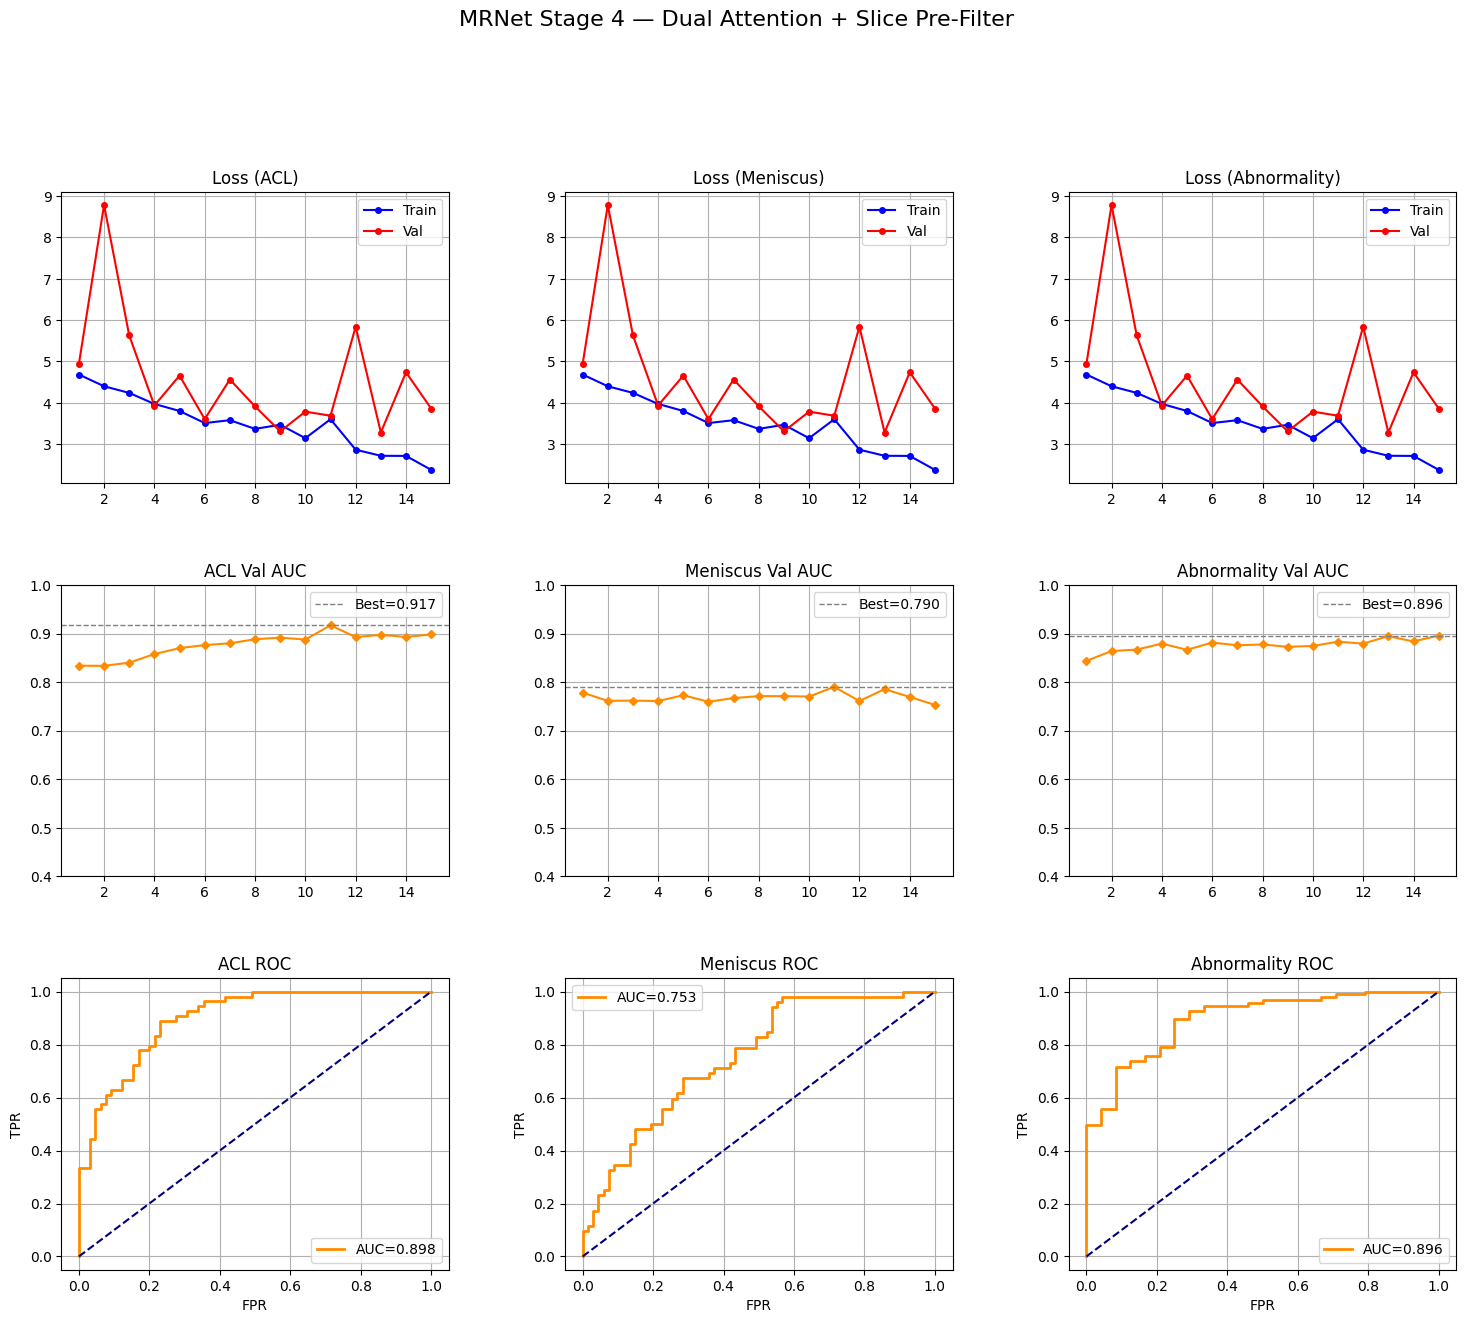

In [114]:
fig, axes = plt.subplots(3, 3, figsize=(18, 14))
plt.subplots_adjust(hspace=0.35, wspace=0.3)
ep = range(1, len(history['train_loss']) + 1)

for i, (key, name) in enumerate(zip(task_keys, task_names)):
    # Loss
    axes[0, i].plot(ep, history['train_loss'], 'b-o', ms=4, label='Train')
    axes[0, i].plot(ep, history['val_loss'],   'r-o', ms=4, label='Val')
    axes[0, i].set_title(f'Loss ({name})')
    axes[0, i].legend(); axes[0, i].grid(True)

    # AUC
    axes[1, i].plot(ep, history[f'val_{key}_auc'], 'darkorange', marker='D', ms=4)
    axes[1, i].axhline(max(history[f'val_{key}_auc']), color='grey',
                        linestyle='--', lw=1,
                        label=f"Best={max(history[f'val_{key}_auc']):.3f}")
    axes[1, i].set_title(f'{name} Val AUC')
    axes[1, i].set_ylim(0.4, 1.0)
    axes[1, i].legend(); axes[1, i].grid(True)

    # ROC
    fpr, tpr, _ = roc_curve(all_val_true[i], all_val_preds[i])
    axes[2, i].plot(fpr, tpr, 'darkorange', lw=2,
                    label=f"AUC={sk_auc(fpr, tpr):.3f}")
    axes[2, i].plot([0,1],[0,1], 'navy', lw=1.5, linestyle='--')
    axes[2, i].set_title(f'{name} ROC'); axes[2, i].set_xlabel('FPR')
    axes[2, i].set_ylabel('TPR'); axes[2, i].legend(); axes[2, i].grid(True)

plt.suptitle('MRNet Stage 4 — Dual Attention + Slice Pre-Filter', fontsize=16, y=1.01)
plt.savefig('/content/drive/MyDrive/MLII Final/stage3_results.png',
            dpi=120, bbox_inches='tight')
plt.show()


In [100]:
class GradCAM:
    """
    Grad-CAM for MRNetDualAttn.
    Target layer: backbone_layers[-1]  (ResNet-18 layer4, 512-ch).
    Computes a single-slice proxy score for each task to generate the map.
    """
    def __init__(self, model: MRNetDualAttn):
        self.model       = model
        self.activations = None
        self.gradients   = None
        target = model.backbone_layers[-1]
        self._h1 = target.register_forward_hook(
            lambda m, i, o: setattr(self, 'activations', o.detach()))
        self._h2 = target.register_full_backward_hook(
            lambda m, gi, go: setattr(self, 'gradients', go[0].detach()))

    def remove(self):
        self._h1.remove(); self._h2.remove()

    def compute(self, vol, pad_mask, task: str = 'acl', slice_idx: int = 0):
        """
        vol      : (B, S, 3, H, W)  single-item batch (B=1)
        pad_mask : (B, S)
        Returns  : cam (H, W) in [0,1],  raw_img (H, W, 3)
        """
        self.model.eval()
        B, S, C, H, W = vol.shape
        slc  = vol[:, slice_idx, :, :, :]          # (1, 3, H, W)
        flat = slc.clone().requires_grad_(True)

        # Forward: backbone → attention → pool → task head
        feat_map = flat
        for layer in self.model.backbone_layers:
            feat_map = layer(feat_map)
        feat_map = self.model.dual_attention(feat_map)
        pooled   = self.model.global_pool(feat_map).flatten(1)   # (1, 512)

        # Replicate view concat (3×same) to match fusion input shape
        fused_in = torch.cat([pooled]*3, dim=1)    # (1, 1536)
        fused    = self.model.fusion(fused_in)      # (1, 256)

        score = {'acl': self.model.head_acl,
                 'men': self.model.head_men,
                 'abn': self.model.head_abn}[task](fused).squeeze()

        self.model.zero_grad()
        score.backward()

        # Grad-CAM
        weights = self.gradients.mean(dim=[-2,-1], keepdim=True)  # (1, C, 1, 1)
        cam = F.relu((weights * self.activations).sum(dim=1).squeeze(0))
        cam = cam.cpu().numpy()
        if cam.max() > 1e-6:
            cam = (cam - cam.min()) / (cam.max() - cam.min())
        cam = cv2.resize(cam, (W, H))

        # Denormalise slice for display
        mean = np.array([0.485,0.456,0.406])
        std  = np.array([0.229,0.224,0.225])
        raw  = flat[0].detach().cpu().numpy().transpose(1,2,0)
        raw  = (raw * std + mean).clip(0,1)
        return cam, raw


def visualise_gradcam(model, valid_loader, device,
                      n_examples=3,
                      tasks=('acl','men','abn'),
                      views=('axial','coronal','sagittal')):
    """
    For each validation example: select the middle real slice per view,
    run Grad-CAM for every task, and plot a task × view grid.
    """
    task_labels = {'acl':'ACL', 'men':'Meniscus', 'abn':'Abnormality'}
    gcam = GradCAM(model)
    view_vols = {'axial': None, 'coronal': None, 'sagittal': None}

    for ex_idx, (ax, cor, sag, pad_mask, labels) in enumerate(valid_loader):
        if ex_idx >= n_examples:
            break
        ax  = ax.to(device)
        cor = cor.to(device)
        sag = sag.to(device)
        pad_mask = pad_mask.to(device)
        view_vols = {'axial': ax, 'coronal': cor, 'sagittal': sag}

        real   = (~pad_mask[0]).nonzero(as_tuple=True)[0]
        mid_s  = real[len(real)//2].item()

        fig, axes = plt.subplots(len(tasks), len(views),
                                  figsize=(5*len(views), 4*len(tasks)))
        fig.suptitle(
            f"Grad-CAM — Val example {ex_idx+1}  "
            f"[ACL={labels[0,0]:.0f}  Men={labels[0,1]:.0f}  Abn={labels[0,2]:.0f}]",
            fontsize=13)

        for ti, task in enumerate(tasks):
            for vi, view in enumerate(views):
                cam, raw = gcam.compute(view_vols[view], pad_mask,
                                         task=task, slice_idx=mid_s)
                ax_p = axes[ti][vi]
                ax_p.imshow(raw, cmap='gray')
                ax_p.imshow(cam, cmap='jet', alpha=0.45)
                ax_p.set_title(f"{task_labels[task]} | {view.capitalize()}", fontsize=10)
                ax_p.axis('off')

        plt.tight_layout()
        out = f'/content/drive/MyDrive/MLII Final/gradcam_ex{ex_idx+1}.png'
        plt.savefig(out, dpi=120, bbox_inches='tight')
        plt.show()
        print(f"  Saved → {out}")

    gcam.remove()


print("Loading best checkpoint for Grad-CAM …")
ckpt_best = torch.load(SAVE_PATH, map_location=DEVICE)
model.load_state_dict(ckpt_best['model_state_dict'])
model.to(DEVICE)
visualise_gradcam(model, valid_loader, DEVICE, n_examples=3)


Loading best checkpoint for Grad-CAM …


UnpicklingError: Weights only load failed. This file can still be loaded, to do so you have two options, [1mdo those steps only if you trust the source of the checkpoint[0m. 
	(1) In PyTorch 2.6, we changed the default value of the `weights_only` argument in `torch.load` from `False` to `True`. Re-running `torch.load` with `weights_only` set to `False` will likely succeed, but it can result in arbitrary code execution. Do it only if you got the file from a trusted source.
	(2) Alternatively, to load with `weights_only=True` please check the recommended steps in the following error message.
	WeightsUnpickler error: Unsupported global: GLOBAL numpy._core.multiarray.scalar was not an allowed global by default. Please use `torch.serialization.add_safe_globals([numpy._core.multiarray.scalar])` or the `torch.serialization.safe_globals([numpy._core.multiarray.scalar])` context manager to allowlist this global if you trust this class/function.

Check the documentation of torch.load to learn 